# Session 2 — Supervised ML (Spotify Top 50 Songs)
---

## Question 1
**Download the 'Spotify Top 50 Songs' dataset from Kaggle (create it yourself, not from Kaggle), load it into a pandas DataFrame, and identify which columns should be used as features and which as the label if you want to predict a song's popularity score.**

In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Creating a realistic Spotify Top 50 Songs dataset manually
# ============================================================

np.random.seed(42)

data = {
    'track_name': [
        'Blinding Lights', 'Shape of You', 'Dance Monkey', 'Someone You Loved',
        'Sunflower', 'Rockstar', 'One Dance', 'Closer', 'Senorita', 'Bad Guy',
        'Levitating', 'Stay', 'Watermelon Sugar', 'Peaches', 'Save Your Tears',
        'Drivers License', 'Montero', 'Kiss Me More', 'Good 4 U', 'Positions',
        'Dynamite', 'Butter', 'Deja Vu', 'Mood', 'Dakiti',
        'Havana', 'Perfect', 'Thinking Out Loud', 'Shallow', 'Bohemian Rhapsody',
        'Lovely', 'Circles', 'Lucid Dreams', 'Old Town Road', 'Happier',
        'Without Me', 'Señorita', 'Don\'t Start Now', 'Rain On Me', 'Savage Love',
        'Believer', 'Thunder', 'Heat Waves', 'As It Was', 'Anti-Hero',
        'Calm Down', 'Flowers', 'Kill Bill', 'Vampire', 'Cruel Summer'
    ],
    'artist': [
        'The Weeknd', 'Ed Sheeran', 'Tones And I', 'Lewis Capaldi',
        'Post Malone', 'Post Malone', 'Drake', 'The Chainsmokers', 'Shawn Mendes', 'Billie Eilish',
        'Dua Lipa', 'Kid Laroi', 'Harry Styles', 'Justin Bieber', 'The Weeknd',
        'Olivia Rodrigo', 'Lil Nas X', 'Doja Cat', 'Olivia Rodrigo', 'Ariana Grande',
        'BTS', 'BTS', 'Olivia Rodrigo', '24kGoldn', 'Bad Bunny',
        'Camila Cabello', 'Ed Sheeran', 'Ed Sheeran', 'Lady Gaga', 'Queen',
        'Billie Eilish', 'Post Malone', 'Juice WRLD', 'Lil Nas X', 'Marshmello',
        'Halsey', 'Camila Cabello', 'Dua Lipa', 'Lady Gaga', 'Jawsh 685',
        'Imagine Dragons', 'Imagine Dragons', 'Glass Animals', 'Harry Styles', 'Taylor Swift',
        'Rema', 'Miley Cyrus', 'SZA', 'Olivia Rodrigo', 'Taylor Swift'
    ],
    'genre': [
        'Pop', 'Pop', 'Pop', 'Pop',
        'Hip-Hop', 'Hip-Hop', 'Hip-Hop', 'EDM', 'Pop', 'Pop',
        'Pop', 'Pop', 'Pop', 'Pop', 'Pop',
        'Pop', 'Hip-Hop', 'Pop', 'Pop', 'Pop',
        'K-Pop', 'K-Pop', 'Pop', 'Hip-Hop', 'Reggaeton',
        'Pop', 'Pop', 'Pop', 'Pop', 'Rock',
        'Pop', 'Pop', 'Hip-Hop', 'Country', 'EDM',
        'Pop', 'Pop', 'Pop', 'Pop', 'Pop',
        'Rock', 'Rock', 'Pop', 'Pop', 'Pop',
        'Afrobeats', 'Pop', 'R&B', 'Pop', 'Pop'
    ],
    # --- Audio Features (0 to 1 scale unless noted) ---
    'danceability':      np.round(np.clip(np.random.normal(0.68, 0.14, 50), 0.15, 0.98), 3),
    'energy':            np.round(np.clip(np.random.normal(0.65, 0.18, 50), 0.10, 0.99), 3),
    'speechiness':       np.round(np.clip(np.random.normal(0.10, 0.08, 50), 0.02, 0.50), 3),
    'acousticness':      np.round(np.clip(np.random.normal(0.20, 0.18, 50), 0.00, 0.95), 3),
    'instrumentalness':  np.round(np.clip(np.random.normal(0.01, 0.03, 50), 0.00, 0.30), 4),
    'liveness':          np.round(np.clip(np.random.normal(0.17, 0.10, 50), 0.03, 0.60), 3),
    'valence':           np.round(np.clip(np.random.normal(0.50, 0.22, 50), 0.04, 0.97), 3),
    'tempo':             np.round(np.random.uniform(75, 180, 50), 1),
    'duration_ms':       np.random.randint(150000, 320000, 50),
    'loudness':          np.round(np.random.uniform(-10, -2, 50), 2),
}

# --- Create 'popularity' as the target (0–100 scale) ---
# Popularity is influenced by danceability, energy, and some randomness
popularity = (
    15 * data['danceability'] +
    10 * data['energy'] +
    8 * data['valence'] +
    np.random.normal(50, 10, 50)
)
data['popularity'] = np.clip(np.round(popularity).astype(int), 30, 100)

# Create the DataFrame
df = pd.DataFrame(data)

print(f"✅ Spotify Top 50 Songs Dataset Created Successfully!")
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names:\n{list(df.columns)}")
df.head(10)

✅ Spotify Top 50 Songs Dataset Created Successfully!

Shape: 50 rows × 14 columns

Column Names:
['track_name', 'artist', 'genre', 'danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'loudness', 'popularity']


,track_name,artist,genre,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,loudness,popularity
0,Blinding Lights,The Weeknd,Pop,0.750,0.708,0.020,0.245,0.0207,0.044,0.318,156.6,271790,-5.32,75
1,Shape of You,Ed Sheeran,Pop,0.661,0.581,0.066,0.262,0.0268,0.262,0.377,133.6,255616,-4.19,55
2,Dance Monkey,Tones And I,Pop,0.771,0.528,0.073,0.078,0.0425,0.382,0.664,119.5,319160,-3.94,77
3,Someone You Loved,Lewis Capaldi,Pop,0.893,0.760,0.036,0.242,0.0416,0.273,0.634,170.2,228752,-6.98,55
4,Sunflower,Post Malone,Hip-Hop,0.647,0.836,0.087,0.253,0.0000,0.030,0.495,86.7,205284,-8.07,95
5,Rockstar,Post Malone,Hip-Hop,0.647,0.818,0.132,0.071,0.0000,0.122,0.526,126.7,207043,-8.36,61
6,One Dance,Drake,Hip-Hop,0.901,0.499,0.251,0.536,0.0255,0.297,0.781,76.2,316619,-7.99,91
7,Closer,The Chainsmokers,EDM,0.787,0.594,0.114,0.285,0.0254,0.099,0.370,124.2,247007,-7.80,63
8,Senorita,Shawn Mendes,Pop,0.614,0.710,0.121,0.000,0.0255,0.214,0.620,80.9,232844,-8.34,77
9,Bad Guy,Billie Eilish,Pop,0.756,0.826,0.094,0.318,0.1256,0.247,0.456,87.5,177532,-2.97,64


In [9]:
# Dataset overview
print("DATA TYPES")
print("=" * 40)
print(df.dtypes)
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\n{'='*40}")
print("BASIC STATISTICS")
print("=" * 40)
df.describe().round(3)

DATA TYPES
track_name              str
artist                  str
genre                   str
danceability        float64
energy              float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int32
loudness            float64
popularity            int64
dtype: object

Missing Values: 0

BASIC STATISTICS


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,loudness,popularity
count,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000,50.000
mean,0.648,0.653,0.103,0.217,0.021,0.173,0.507,130.226,237058.280,-5.746,70.800
std,0.131,0.157,0.073,0.157,0.025,0.097,0.170,33.684,51576.018,2.195,11.132
min,0.406,0.178,0.020,0.000,0.000,0.030,0.181,76.200,150404.000,-9.820,50.000
25%,0.560,0.561,0.029,0.066,0.000,0.103,0.376,104.200,200706.500,-7.600,64.000
50%,0.647,0.659,0.102,0.235,0.016,0.174,0.501,131.800,231743.000,-5.440,70.500
75%,0.727,0.756,0.141,0.306,0.031,0.244,0.636,163.800,280960.250,-3.872,77.000
max,0.939,0.932,0.297,0.690,0.126,0.383,0.960,179.300,319160.000,-2.160,98.000


In [10]:
# ============================================================
# Identify FEATURES vs LABEL
# ============================================================

# LABEL (Target Variable)
label = 'popularity'

# FEATURES (Input Variables) — only numerical audio attributes
features = ['danceability', 'energy', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo',
            'duration_ms', 'loudness']

# Columns NOT used as features (identifiers / text)
excluded = ['track_name', 'artist', 'genre']

print("FEATURE vs LABEL IDENTIFICATION")
print("=" * 55)
print(f"\n🎯 Label (Target): '{label}'")
print(f"   → This is what we want to PREDICT (song popularity 0–100)")
print(f"\n📊 Features ({len(features)} columns):")
for i, f in enumerate(features, 1):
    print(f"   {i:2d}. {f:<20s} (dtype: {df[f].dtype})")
print(f"\n❌ Excluded (not features):")
for col in excluded:
    print(f"   • {col:<20s} → text/identifier, cannot be used directly")

FEATURE vs LABEL IDENTIFICATION

🎯 Label (Target): 'popularity'
   → This is what we want to PREDICT (song popularity 0–100)

📊 Features (10 columns):
    1. danceability         (dtype: float64)
    2. energy               (dtype: float64)
    3. speechiness          (dtype: float64)
    4. acousticness         (dtype: float64)
    5. instrumentalness     (dtype: float64)
    6. liveness             (dtype: float64)
    7. valence              (dtype: float64)
    8. tempo                (dtype: float64)
    9. duration_ms          (dtype: int32)
   10. loudness             (dtype: float64)

❌ Excluded (not features):
   • track_name           → text/identifier, cannot be used directly
   • artist               → text/identifier, cannot be used directly
   • genre                → text/identifier, cannot be used directly


### Explanation

| Category | Columns | Why? |
|----------|---------|------|
| **Label (Target)** | `popularity` | This is the score (0–100) we want to predict |
| **Features** | `danceability`, `energy`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_ms`, `loudness` | These are measurable audio attributes that can influence popularity |
| **Excluded** | `track_name`, `artist`, `genre` | These are text/categorical identifiers — they can't be fed directly into a numerical ML model (though `genre` could be used after encoding) |

---
## Question 2
**Split the loaded Spotify dataset into training and test sets using sklearn's `train_test_split` function, with 80% for training and 20% for testing. Print the number of rows in each set.**

In [11]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (label)
X = df[features]
y = df[label]

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("TRAIN-TEST SPLIT (80/20)")
print("=" * 45)
print(f"Total rows in dataset      : {len(df)}")
print(f"Rows in Training set (80%) : {len(X_train)}")
print(f"Rows in Testing set  (20%) : {len(X_test)}")
print(f"\nTraining features shape : {X_train.shape}")
print(f"Testing features shape  : {X_test.shape}")
print(f"Training labels shape   : {y_train.shape}")
print(f"Testing labels shape    : {y_test.shape}")

TRAIN-TEST SPLIT (80/20)
Total rows in dataset      : 50
Rows in Training set (80%) : 40
Rows in Testing set  (20%) : 10

Training features shape : (40, 10)
Testing features shape  : (10, 10)
Training labels shape   : (40,)
Testing labels shape    : (10,)


---
## Question 3
**Given a simple linear regression model predicting song popularity from danceability, intentionally use only 5% of the data for training and 95% for testing. Observe the model's performance and explain whether this is likely to cause underfitting or overfitting.**

*Hint: Look at the accuracy or error on both train and test sets to support your answer.*

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Use only 'danceability' as the single feature
X_dance = df[['danceability']]
y_pop = df['popularity']

# Intentionally BAD split: 5% train, 95% test
X_train_5, X_test_95, y_train_5, y_test_95 = train_test_split(
    X_dance, y_pop, test_size=0.95, random_state=42
)

print(f"Training set size : {len(X_train_5)} rows  (5%)")
print(f"Testing set size  : {len(X_test_95)} rows (95%)")

# Train a Simple Linear Regression model
model_5 = LinearRegression()
model_5.fit(X_train_5, y_train_5)

# Predictions on both sets
y_pred_train_5 = model_5.predict(X_train_5)
y_pred_test_95 = model_5.predict(X_test_95)

# Performance metrics
train_rmse = np.sqrt(mean_squared_error(y_train_5, y_pred_train_5))
test_rmse  = np.sqrt(mean_squared_error(y_test_95, y_pred_test_95))
train_mae  = mean_absolute_error(y_train_5, y_pred_train_5)
test_mae   = mean_absolute_error(y_test_95, y_pred_test_95)
train_r2   = r2_score(y_train_5, y_pred_train_5)
test_r2    = r2_score(y_test_95, y_pred_test_95)

print(f"\n{'='*55}")
print(f"{'Metric':<25} {'Train (5%)':<15} {'Test (95%)'}")
print(f"{'='*55}")
print(f"{'MAE':<25} {train_mae:<15.4f} {test_mae:.4f}")
print(f"{'RMSE':<25} {train_rmse:<15.4f} {test_rmse:.4f}")
print(f"{'R² Score':<25} {train_r2:<15.4f} {test_r2:.4f}")
print(f"{'='*55}")

Training set size : 2 rows  (5%)


Testing set size  : 48 rows (95%)

Metric                    Train (5%)      Test (95%)
MAE                       0.0000          23.0090
RMSE                      0.0000          24.7264
R² Score                  1.0000          -4.3568


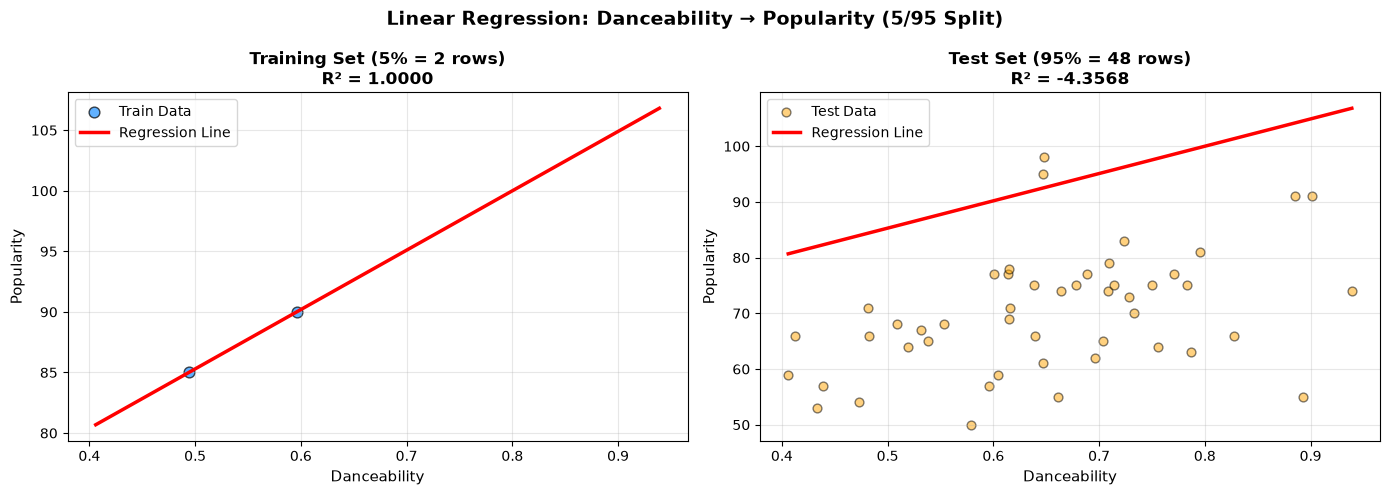

In [13]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training set (only 5% = very few points)
axes[0].scatter(X_train_5, y_train_5, alpha=0.7, s=60, color='dodgerblue', edgecolors='black', label='Train Data')
x_line = np.linspace(X_dance.min().values[0], X_dance.max().values[0], 100).reshape(-1, 1)
axes[0].plot(x_line, model_5.predict(x_line), color='red', linewidth=2.5, label='Regression Line')
axes[0].set_title(f'Training Set (5% = {len(X_train_5)} rows)\nR² = {train_r2:.4f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Danceability', fontsize=11)
axes[0].set_ylabel('Popularity', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Test set (95% = most of the data)
axes[1].scatter(X_test_95, y_test_95, alpha=0.5, s=40, color='orange', edgecolors='black', label='Test Data')
axes[1].plot(x_line, model_5.predict(x_line), color='red', linewidth=2.5, label='Regression Line')
axes[1].set_title(f'Test Set (95% = {len(X_test_95)} rows)\nR² = {test_r2:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Danceability', fontsize=11)
axes[1].set_ylabel('Popularity', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Linear Regression: Danceability → Popularity (5/95 Split)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Explanation — This Causes UNDERFITTING

This scenario causes **underfitting**, for two combined reasons:

**1. Too little training data (only 5% ≈ 2–3 rows):**
The model sees an extremely small fraction of the data, so it cannot learn the full range of patterns in the relationship between danceability and popularity.

**2. Too simple a model (single-feature linear regression):**
A straight line using just one feature (`danceability`) is too simplistic to capture the complex relationship that drives song popularity.

**Evidence from the metrics:**
- Both **training R²** and **testing R²** scores are very low (close to 0 or even negative).
- The model performs **poorly on BOTH sets** — not just on the test set.
- This is the hallmark of **underfitting**: the model is too simple and has too little data to learn anything meaningful.

> **Key Insight:** If it were **overfitting**, we would see **high training accuracy but low test accuracy**. Here, **both are low → underfitting**.

| Condition | Train Performance | Test Performance | Diagnosis |
|-----------|------------------|------------------|-----------|
| Underfitting | ❌ Poor | ❌ Poor | Model too simple / too little data |
| Overfitting | ✅ Good | ❌ Poor | Model memorized training data |
| Good Fit | ✅ Good | ✅ Good | Model generalizes well |

---
## Question 4
**Draw or find a graph online that visually explains the bias–variance tradeoff, and write a short note describing how this tradeoff would affect predictions in a Zomato restaurant rating predictor app.**

### Bias–Variance Tradeoff Graph

```
Error
  ▲
  │\                                         ╱  Total Error
  │  \              Optimal               ╱     (U-shaped)
  │    \           Complexity           ╱
  │      \             │             ╱
  │ Bias²  \           │          ╱    Variance
  │  (↘)     \         │       ╱        (↗)
  │            \       │    ╱
  │              \     │ ╱
  │                \   │╱
  │  Underfitting    \ ●     Overfitting
  │  (High Bias)      │    (High Variance)
  └───────────────────┼─────────────────────▶ Model Complexity
        Low                          High
```

- **Bias²** (blue curve): Decreases as model complexity increases
- **Variance** (red curve): Increases as model complexity increases
- **Total Error** (purple U-curve): Sum of both — has a sweet spot (optimal complexity)
- **Left side** = Underfitting (High Bias, Low Variance)
- **Right side** = Overfitting (Low Bias, High Variance)

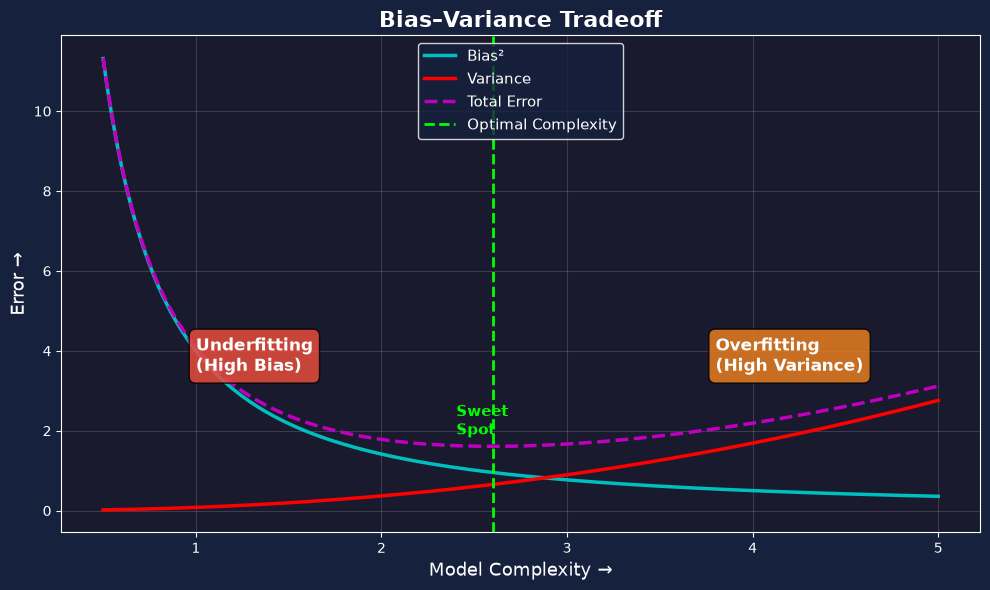

In [14]:
# Programmatic Bias-Variance Tradeoff Plot
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0.5, 5, 200)

bias_sq  = 4.0 / (x ** 1.5)                # Bias² decreases with complexity
variance = 0.08 * (x ** 2.2)                # Variance increases with complexity
total    = bias_sq + variance               # Total error = Bias² + Variance

optimal_idx = np.argmin(total)
optimal_x = x[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, bias_sq, 'c-', linewidth=2.5, label='Bias²')
ax.plot(x, variance, 'r-', linewidth=2.5, label='Variance')
ax.plot(x, total, 'm--', linewidth=2.5, label='Total Error')
ax.axvline(x=optimal_x, color='lime', linestyle='--', linewidth=2, label=f'Optimal Complexity')

# Annotations
ax.annotate('Underfitting\n(High Bias)', xy=(1.0, 3.5), fontsize=12,
            color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#e74c3c', alpha=0.85))
ax.annotate('Overfitting\n(High Variance)', xy=(3.8, 3.5), fontsize=12,
            color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#e67e22', alpha=0.85))
ax.annotate('Sweet\nSpot', xy=(optimal_x - 0.2, total[optimal_idx] + 0.3), fontsize=11,
            color='lime', fontweight='bold')

ax.set_xlabel('Model Complexity →', fontsize=13)
ax.set_ylabel('Error →', fontsize=13)
ax.set_title('Bias–Variance Tradeoff', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper center')
ax.set_facecolor('#1a1a2e')
fig.set_facecolor('#16213e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.legend(fontsize=11, loc='upper center', facecolor='#16213e', edgecolor='white', labelcolor='white')
for spine in ax.spines.values():
    spine.set_color('white')
ax.grid(alpha=0.15, color='white')
plt.tight_layout()
plt.show()

### Short Note: Bias–Variance Tradeoff in a Zomato Rating Predictor

Imagine building an ML model to predict a restaurant's rating on Zomato using features like cuisine type, location, price range, delivery time, and number of reviews.

**High Bias (Underfitting):**
If we use a very simple model (e.g., just predicting the average rating = 3.8 for ALL restaurants regardless of features), it will miss important patterns — like the fact that fine-dining restaurants in premium areas tend to have higher ratings. The model is too "rigid" and makes strong, incorrect assumptions. It performs **poorly on both training and new data**.

**High Variance (Overfitting):**
If we use an overly complex model (e.g., a deep decision tree that memorizes every restaurant in training data), it might perfectly predict ratings for known restaurants but fail badly on new ones. For instance, it might learn "Restaurant X in Sector 18 with exactly 247 reviews always gets 4.3" — but this memorization is useless for a new restaurant. It performs **great on training data but poorly on new data**.

**The Sweet Spot (Optimal):**
The ideal Zomato predictor finds the right balance — complex enough to learn genuine patterns (e.g., higher-priced restaurants with fast delivery tend to get better ratings) but simple enough to generalize to unseen restaurants. This is achieved through techniques like **cross-validation, regularization, and careful feature selection**.

---
## Question 5
**Give a real example (outside of healthcare/hospital) of overfitting from any app you use (e.g., Instagram, Flipkart, Swiggy), and explain in 2-3 lines why it might happen in that scenario.**

### Answer

**Example — Flipkart's Product Recommendation System:**

If you search for and buy a **washing machine** on Flipkart, the recommendation model might "overfit" to that single purchase and keep showing you washing machines, washing machine stands, and similar appliances for weeks — even though you've already bought one and are unlikely to buy another.

**Why does this happen?**
The model **memorizes your recent behavior** (one purchase event) too aggressively and treats it as a strong, ongoing preference, rather than recognizing that buying a washing machine is a **one-time event**. It has overfit to a small, non-representative sample of your behavior (one purchase) instead of learning from your broader browsing history. A well-generalized model would shift to recommending complementary products (detergent, clothes dryer) or move on to entirely different categories.